In [166]:
import pandas as pd
import numpy as np
from scipy import stats

import datetime as dt
from operator import attrgetter

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors


# Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv') #здесь есть NAN во времени подтверждения заказа, передачи достващикам и времени самой доставки
order_items = pd.read_csv('olist_order_items_dataset.csv')

In [3]:
#переводим все даты в формат datetime

order_items['shipping_limit_date'] = pd.to_datetime(order_items.shipping_limit_date)
orders['order_approved_at'] = pd.to_datetime(orders.order_approved_at)
orders['order_purchase_timestamp'] = pd.to_datetime(orders.order_purchase_timestamp)
orders['order_delivered_carrier_date'] = pd.to_datetime(orders.order_delivered_carrier_date)
orders['order_delivered_customer_date'] = pd.to_datetime(orders.order_delivered_customer_date)
orders['order_estimated_delivery_date'] = pd.to_datetime(orders.order_estimated_delivery_date)

In [4]:
#есть много Null-значений в 3 столбцах
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [5]:
#2980 строк с Null-значениями
missing_rows = orders.isnull().any(axis=1)
orders[missing_rows]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [6]:
#проверяем, есть ли среди них доставленные заказы, так как именно их мы будем учитывать для расчёта retention
orders[missing_rows].query('order_status == "delivered"')

# В целом, здесь Null-значения нам никак не помешают в определении retention, поэтому не нужно от них избавляться. 
# Кроме того, проопусков в столбце order_purchase_timestamp нет 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22


In [7]:
# здесь я понял, что для каждого уникального пользователя может быть больше одного customer_id
customers.groupby('customer_unique_id').agg({'customer_id': 'count'}).reset_index().query('customer_id != 1')

,customer_unique_id,customer_id
33,00172711b30d52eea8b313a7f2cced02,2
106,004288347e5e88a27ded2bb23747066c,2
124,004b45ec5c64187465168251cd1c9c2f,2
144,0058f300f57d7b93c477a131a59b36c3,2
249,00a39521eb40f7012db50455bf083460,2
...,...,...
95784,ff36be26206fffe1eb37afd54c70e18b,3
95810,ff44401d0d8f5b9c54a47374eb48c1b8,2
95916,ff8892f7c26aa0446da53d01b18df463,2
95934,ff922bdd6bafcdf99cb90d7f39cea5b3,3


In [8]:
# добавляем уникальные id пользователей в таблицу заказов 
# и проверяем, не образовалось ли Null-объектов в столбце customer_unique_id
delivered_orders = pd.merge(orders, customers[['customer_unique_id','customer_id']], on = 'customer_id', how = 'left')
delivered_orders.customer_unique_id.info()


<class 'pandas.core.series.Series'>
Int64Index: 99441 entries, 0 to 99440
Series name: customer_unique_id
Non-Null Count  Dtype 
--------------  ----- 
99441 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [9]:
#оставляем только доставленные заказы, customer_unique_id и order_purchase_timestamp
delivered_orders = delivered_orders.query('order_status == "delivered"')[['customer_unique_id', 'order_status', 'order_purchase_timestamp']]
delivered_orders

,customer_unique_id,order_status,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05
99437,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58
99438,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43
99439,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27


In [10]:
# здесь я проверил, есть ли пользователи, которые сделали больше одного заказа
delivered_orders.groupby('customer_unique_id').agg({'order_purchase_timestamp': 'count'}).reset_index().query('order_purchase_timestamp > 1')

,customer_unique_id,order_purchase_timestamp
104,004288347e5e88a27ded2bb23747066c,2
243,00a39521eb40f7012db50455bf083460,2
305,00cc12a6d8b578b8ebd21ea4e2ae8b27,2
404,011575986092c30523ecb71ff10cb473,2
419,011b4adcd54683b480c4d841250a987f,2
...,...,...
92991,ff03923ad1eb9e32304deb7f9b2a45c9,2
93085,ff44401d0d8f5b9c54a47374eb48c1b8,2
93187,ff8892f7c26aa0446da53d01b18df463,2
93205,ff922bdd6bafcdf99cb90d7f39cea5b3,3


In [11]:
# определяем когорты
delivered_orders['cohort'] = delivered_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
delivered_orders['cohort_day'] = delivered_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')
delivered_orders

,customer_unique_id,order_status,order_purchase_timestamp,cohort,cohort_day
0,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-09,2017-09-04
1,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07,2018-07-24
2,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08,2018-08-08
3,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11,2017-11-18
4,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02,2018-02-13
...,...,...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,2017-03,2017-03-09
99437,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,2018-02,2018-02-06
99438,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,2017-08,2017-08-27
99439,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,2018-01,2018-01-08


In [12]:
# определяем номер периода для когорт
delivered_orders['period_number'] = np.floor((delivered_orders.order_purchase_timestamp.dt.to_period('D') - delivered_orders.cohort_day).apply(attrgetter('n')) / 30)
delivered_orders

,customer_unique_id,order_status,order_purchase_timestamp,cohort,cohort_day,period_number
0,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-09,2017-09-04,0.0
1,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07,2018-07-24,0.0
2,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08,2018-08-08,0.0
3,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11,2017-11-18,0.0
4,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02,2018-02-13,0.0
...,...,...,...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,2017-03,2017-03-09,0.0
99437,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,2018-02,2018-02-06,0.0
99438,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,2017-08,2017-08-27,0.0
99439,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,2018-01,2018-01-08,0.0


In [13]:
#узнаём количество уникальных пользователей в когортах
df_cohort = delivered_orders.groupby(['cohort', 'period_number']).agg(un_customers=('customer_unique_id', 'nunique')).reset_index()
df_cohort

,cohort,period_number,un_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1
...,...,...,...
210,2018-06,1.0,22
211,2018-06,2.0,6
212,2018-07,0.0,5949
213,2018-07,1.0,6


In [14]:
#соединяем данные по когортам и периодам в одной таблице
cohort_pivot = df_cohort.pivot_table(index = 'cohort', columns = 'period_number', values = 'un_customers')
cohort_pivot


period_number,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN
2017-03,2503.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,6.0,6.0,...,4.0,4.0,3.0,7.0,2.0,3.0,2.0,NaN,NaN,NaN
2017-04,2256.0,8.0,6.0,1.0,6.0,8.0,6.0,10.0,5.0,6.0,...,3.0,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN
2017-05,3451.0,14.0,14.0,8.0,13.0,11.0,11.0,4.0,10.0,9.0,...,11.0,6.0,3.0,7.0,4.0,NaN,NaN,NaN,NaN,NaN
2017-06,3037.0,13.0,15.0,11.0,5.0,16.0,9.0,6.0,4.0,10.0,...,9.0,3.0,9.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#устанавливаем размеры когорт в 0 месяце
cohort_size = cohort_pivot.iloc[:,0]
cohort_size

cohort
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Freq: M, Name: 0.0, dtype: float64

In [16]:
#узнаём retention делением всех столбцов на первый столбец
retention_matrix = cohort_pivot.divide(cohort_size, axis = 0)
retention_matrix

period_number,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN
2017-03,1.0,0.002797,0.005194,0.004395,0.001199,0.000799,0.003596,0.001598,0.002397,0.002397,...,0.001598,0.001598,0.001199,0.002797,0.000799,0.001199,0.000799,NaN,NaN,NaN
2017-04,1.0,0.003546,0.002660,0.000443,0.002660,0.003546,0.002660,0.004433,0.002216,0.002660,...,0.001330,NaN,0.000887,0.000887,0.000887,0.000887,NaN,NaN,NaN,NaN
2017-05,1.0,0.004057,0.004057,0.002318,0.003767,0.003187,0.003187,0.001159,0.002898,0.002608,...,0.003187,0.001739,0.000869,0.002028,0.001159,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004281,0.004939,0.003622,0.001646,0.005268,0.002963,0.001976,0.001317,0.003293,...,0.002963,0.000988,0.002963,0.001317,NaN,NaN,NaN,NaN,NaN,NaN


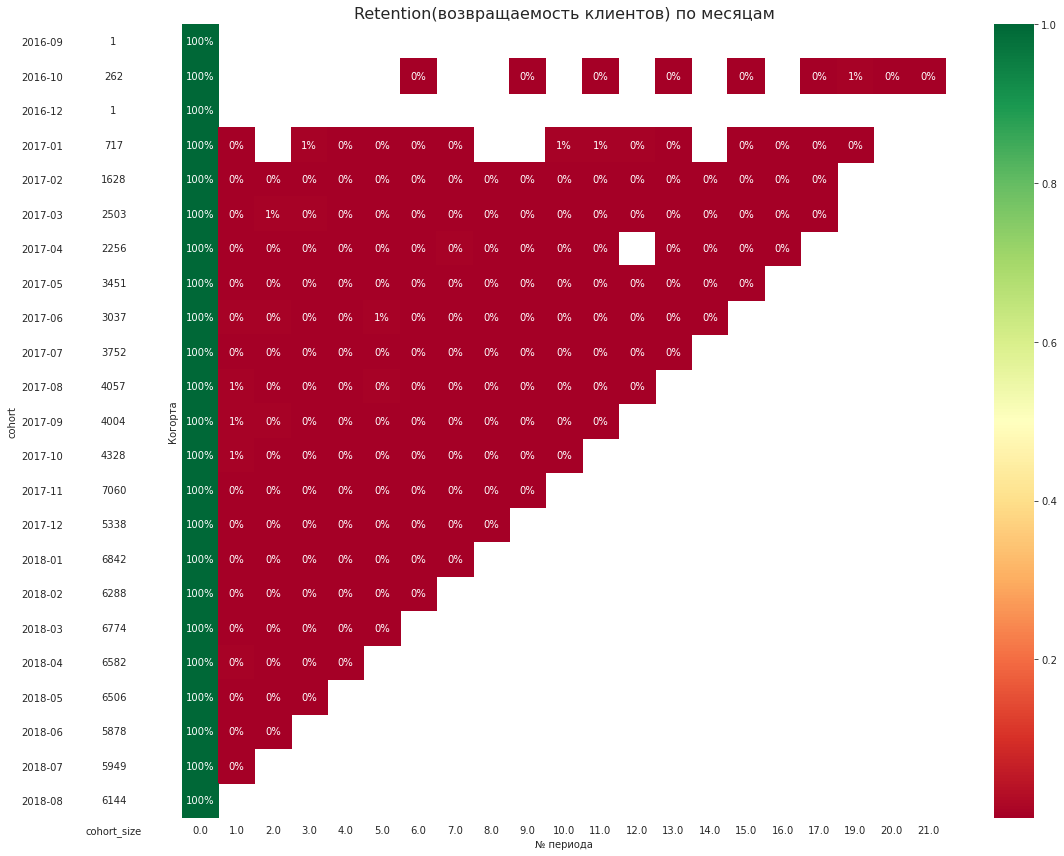

In [252]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Retention(возвращаемость клиентов) по месяцам', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [18]:
#всё плохо

In [231]:
#определяем медианный retention 1 месяца в процентах
median_retention_1 = retention_matrix.iloc[:,1].median()

In [20]:
#определяем самый большой retention 3 месяца в процентах
max_retention_3 = retention_matrix.iloc[:,3].max()*100
max_retention_3

0.5578800557880056

In [21]:
retention_matrix.iloc[0:,3]

#самый высокий retention за 3 месяц будет в когорте января 2017 года

cohort
2016-09         NaN
2016-10         NaN
2016-12         NaN
2017-01    0.005579
2017-02    0.003686
2017-03    0.004395
2017-04    0.000443
2017-05    0.002318
2017-06    0.003622
2017-07    0.002399
2017-08    0.003451
2017-09    0.003247
2017-10    0.001155
2017-11    0.001558
2017-12    0.001873
2018-01    0.003362
2018-02    0.002704
2018-03    0.002362
2018-04    0.002279
2018-05    0.000615
2018-06         NaN
2018-07         NaN
2018-08         NaN
Freq: M, Name: 3.0, dtype: float64

In [22]:
# для построения визуализаций медианного и максимального retention задаём функции, которые приведут данные в удобный вид
def fmed(df):
    n = []
    for period in range(0, len(df)-1):
        if period in df:
            n.append(df[period].median())
    new_df = pd.DataFrame(n, columns = ['median'])
    return new_df
def fmax(df):
    n = []
    for period in range(0, len(df)-1):
        if period in df:
            n.append(df[period].max())
    new_df = pd.DataFrame(n, columns = ['max'])
    return new_df

#p.s. 18 период у всех когорт отсутствует (значение Null), поэтому им мы можем пренебречь

In [23]:
# формируем Датафрейм с данными по максимумам и медианам в когортах по периодам
medians_and_maxes = pd.DataFrame()
medians_and_maxes['medians'] = fmed(cohort_pivot)
medians_and_maxes['maxes'] = fmax(cohort_pivot)
medians_and_maxes = medians_and_maxes.reset_index()
medians_and_maxes

,index,medians,maxes
0,0,4057.0,7060.0
1,1,19.0,30.0
2,2,13.0,23.0
3,3,11.0,23.0
4,4,11.0,16.0
5,5,9.0,19.0
6,6,9.0,17.0
7,7,6.0,17.0
8,8,5.0,13.0
9,9,7.0,10.0


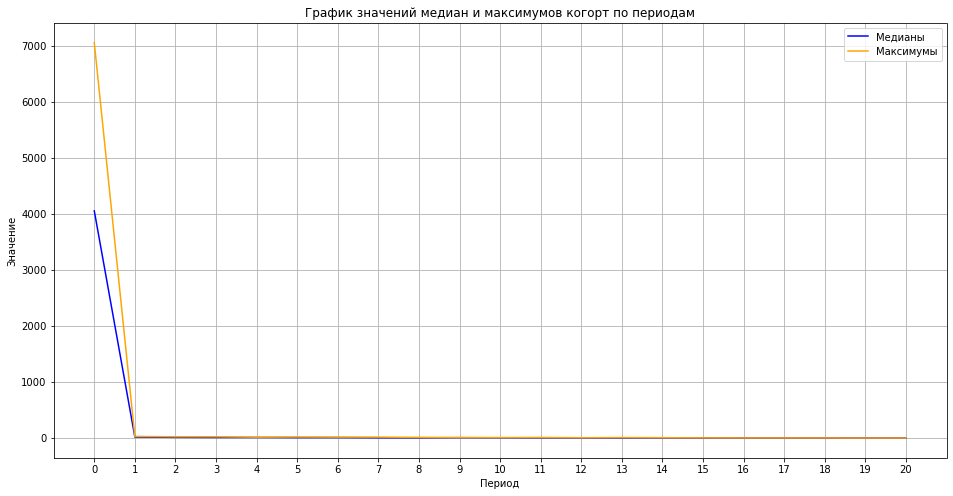

In [55]:
#собственно, сам график
plt.figure(figsize=(16,8))
plt.plot(medians_and_maxes.index, medians_and_maxes.medians, label='Медианы', color='blue')
plt.plot(medians_and_maxes.index, medians_and_maxes.maxes, label='Максимумы', color='orange')

plt.xlabel('Период')  
plt.ylabel('Значение')  
plt.title('График значений медиан и максимумов когорт по периодам') 
plt.xticks(medians_and_maxes.index)
plt.legend()
plt.grid()

# Задача 2. Определить, существует ли product/market fit у маркетплейса.

([<matplotlib.axis.XTick at 0x7f4beabf4f40>,
 <a list of 21 Text major ticklabel objects>)

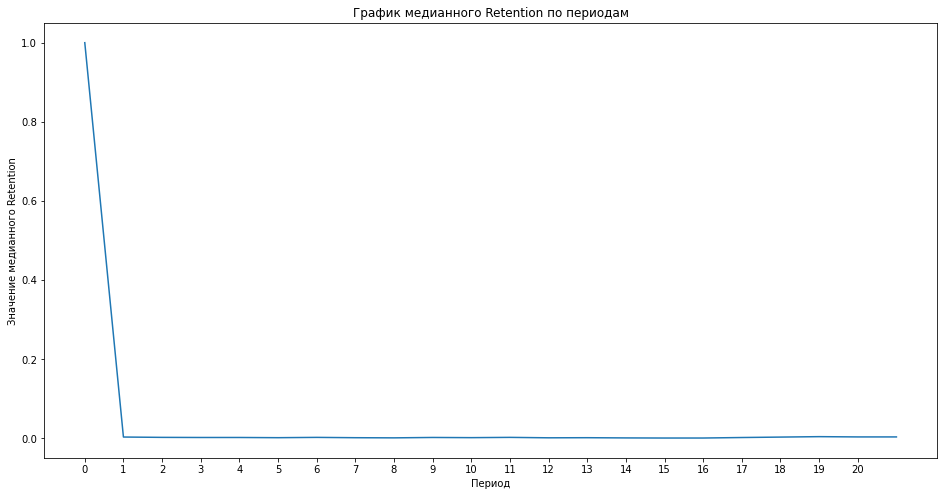

In [112]:
plt.figure(figsize=(16,8))
retention_matrix.median().plot()
plt.xlabel('Период')  
plt.ylabel('Значение медианного Retention')  
plt.title('График медианного Retention по периодам') 
plt.xticks(medians_and_maxes.index)

In [25]:
#видим, что уже к началу второго месяца использования и медианы, и максимумы по когортам стремятся к нулю. 
#Да и retention у всех когорт околонулевой, что говорит о плохом удержании клиентов в продукте.

#исходя из значений retention, а также графиков по медианам и максимумам среди всех когорт по месяцам можно сказать, 
#что product/market fit у данного маркетплейса отсутствует. 
#Большинство (более 90% всех новых клиентов) уходят после совершения 1 покупки в приложении.

#Масштабироваться с таким product/market fit НЕЛЬЗЯ.

In [117]:
#выясним, почему нет удержания клиентов. 
#Причин может быть много - неудобное приложение, отсутствие необходимых товаров на маркетплейсе, 
#отсутствие предложения похожих товаров и рекомендаций на основании предыдущих покупок и активности пользователей,
#а может это результат долгой доставки товара.

# Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Первая метрика должна отражать рост объёма продаж маркетплейса. 

Эта метрика - среднее количество заказов на одного клиента.



In [123]:
#у нас уже есть таблица с доставленными заказами и уникальными id пользователей на каждый
delivered_orders

,customer_unique_id,order_status,order_purchase_timestamp,cohort,cohort_day,period_number
0,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-09,2017-09-04,0.0
1,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07,2018-07-24,0.0
2,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08,2018-08-08,0.0
3,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11,2017-11-18,0.0
4,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02,2018-02-13,0.0
...,...,...,...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:05,2017-03,2017-03-09,0.0
99437,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:58,2018-02,2018-02-06,0.0
99438,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:43,2017-08,2017-08-27,0.0
99439,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:27,2018-01,2018-01-08,0.0


In [126]:
#группируем по уникальному id клиента
me = delivered_orders.groupby('customer_unique_id').agg({'order_purchase_timestamp': 'count'}).reset_index()
me

,customer_unique_id,order_purchase_timestamp
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1
93354,fffea47cd6d3cc0a88bd621562a9d061,1
93355,ffff371b4d645b6ecea244b27531430a,1
93356,ffff5962728ec6157033ef9805bacc48,1


In [132]:
# считаем среднее количество заказов на одного пользователя в целом за всё время
mean_orders = me.order_purchase_timestamp.mean()
mean_orders

1.0334197390689603

In [152]:
#далее - разобъём её по месяцам
mean_orders_month = delivered_orders.groupby(['cohort', 'customer_unique_id']).agg({'order_purchase_timestamp':'count'}).reset_index()
mean_orders_month

,cohort,customer_unique_id,order_purchase_timestamp
0,2016-09,830d5b7aaa3b6f1e9ad63703bec97d23,1
1,2016-10,0032c76b20340da25249092a268ce66c,1
2,2016-10,01f156677184504063bd19739f924af1,1
3,2016-10,0636d30c77f0f9cfad81f1c9b58c791f,1
4,2016-10,06bdfbbe1857c3c925ec81abfb1c9666,1
...,...,...,...
93353,2018-08,ffc39051848c3ef2be36d1513aa3ad17,1
93354,2018-08,ffc4e1cd8aa220763480d0a18157c45d,1
93355,2018-08,ffe204b1bb8026741b839085b2fd10f2,1
93356,2018-08,ffec490ab531184a483efe2eedd68908,1


In [169]:
mean_orders_month =mean_orders_month.groupby('cohort').agg({'order_purchase_timestamp': 'mean'}).rename(columns={'order_purchase_timestamp':'mean_orders'})
mean_orders_month

,mean_orders
cohort,
2016-09,1.000000
2016-10,1.049618
2016-12,2.000000
2017-01,1.092050
2017-02,1.044840
2017-03,1.056332
2017-04,1.049202
2017-05,1.062301
2017-06,1.062232


<Figure size 1152x576 with 0 Axes>

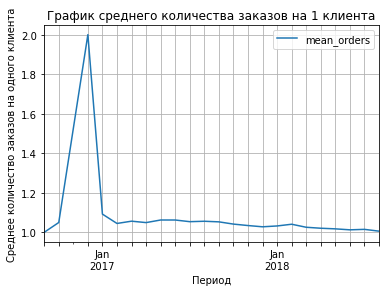

In [184]:
plt.figure(figsize=(16,8))
#почему-то команда с размерами графика не сработала
mean_orders_month.plot()
plt.xlabel('Период')  
plt.ylabel('Среднее количество заказов на одного клиента')  
plt.title('График среднего количества заказов на 1 клиента') 
plt.xticks(mean_orders_month.index)
plt.grid()

Вторая — показывать объем аудитории, которой продукт доставляет ценность.

Это количество активных пользователей по месяцам

In [177]:
#для этого просто группируем пользователей, сделавших заказы, по месяцам заказов
active_users = delivered_orders.groupby('cohort').agg({'customer_unique_id':"count"})
active_users

,customer_unique_id
cohort,
2016-09,1
2016-10,275
2016-12,2
2017-01,783
2017-02,1701
2017-03,2644
2017-04,2367
2017-05,3666
2017-06,3226


In [181]:
#среднее количество активных клиентов за всё время
active_users.mean()

customer_unique_id    4194.695652
dtype: float64

<Figure size 1152x576 with 0 Axes>

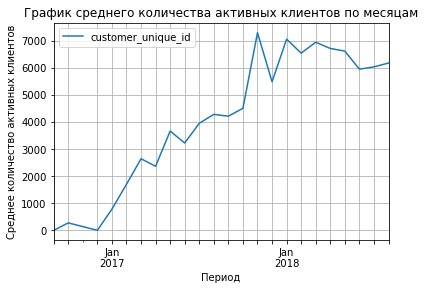

In [186]:

plt.figure(figsize=(16,8))
active_users.plot()
plt.xlabel('Период')  
plt.ylabel('Среднее количество активных клиентов')  
plt.title('График среднего количества активных клиентов по месяцам') 
plt.xticks(active_users.index)
plt.grid()


Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).

Это конверсия в оплату

Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.

Это retention

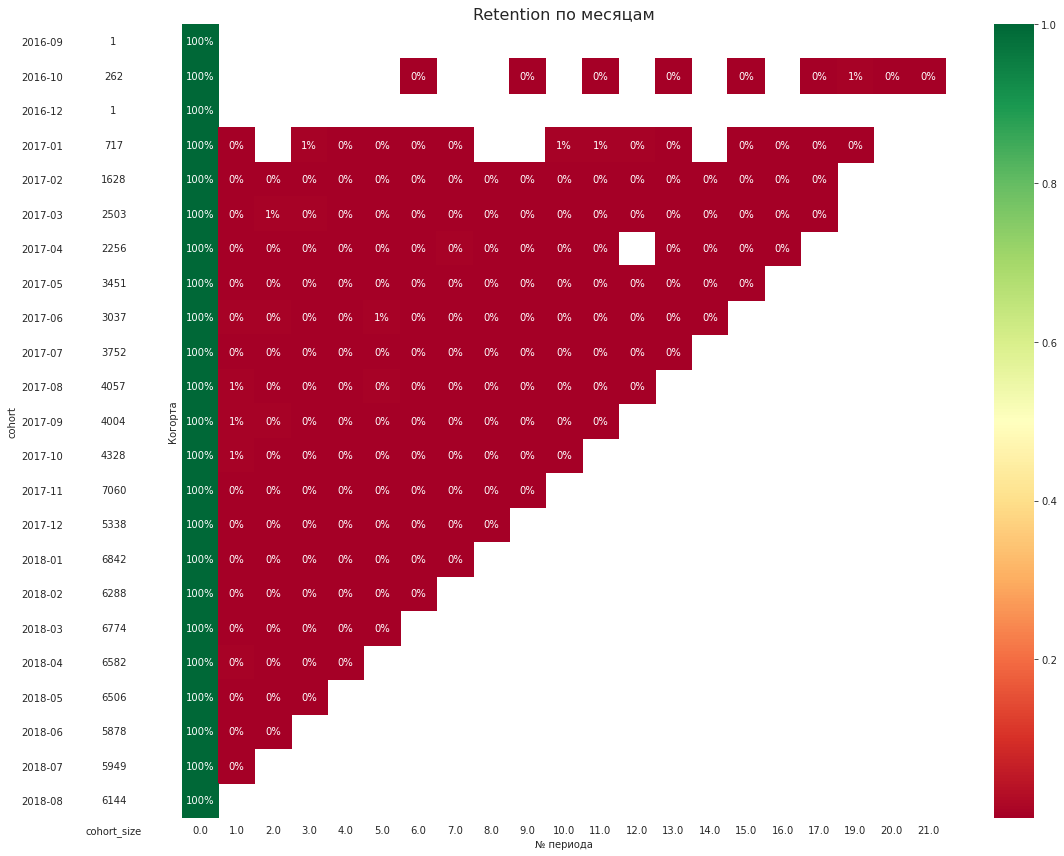

In [187]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Retention по месяцам', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

Пятая — отражать денежное выражение вовлеченности клиента.

Это средняя сумма заказа

In [206]:
mean_order_price = order_items.groupby('order_id').agg({'price':'sum'}).reset_index()
mean_order_price

,order_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99
98662,fffcd46ef2263f404302a634eb57f7eb,350.00
98663,fffce4705a9662cd70adb13d4a31832d,99.90
98664,fffe18544ffabc95dfada21779c9644f,55.99


In [207]:
#средняя сумма заказа за всё врремя
mean_order_price.price.mean()

137.7540763788945

In [208]:
mean_order_price = pd.merge(mean_order_price, orders[['order_id', 'order_purchase_timestamp']], on = 'order_id', how='inner')
mean_order_price['order_purchase_timestamp'] = mean_order_price.order_purchase_timestamp.dt.to_period('M')
mean_order_price

,order_id,price,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,2017-09
1,00018f77f2f0320c557190d7a144bdd3,239.90,2017-04
2,000229ec398224ef6ca0657da4fc703e,199.00,2018-01
3,00024acbcdf0a6daa1e931b038114c75,12.99,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,2017-02
...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,2018-04
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,2018-07
98663,fffce4705a9662cd70adb13d4a31832d,99.90,2017-10
98664,fffe18544ffabc95dfada21779c9644f,55.99,2017-08


In [209]:
mean_order_price = mean_order_price.groupby('order_purchase_timestamp').agg({'price': 'mean'}).reset_index()
mean_order_price

,order_purchase_timestamp,price
0,2016-09,89.120000
1,2016-10,160.739156
2,2016-12,10.900000
3,2017-01,152.487795
4,2017-02,142.702262
5,2017-03,141.743393
6,2017-04,150.534182
7,2017-05,138.270803
8,2017-06,134.609450
9,2017-07,125.480343


<Figure size 1152x576 with 0 Axes>

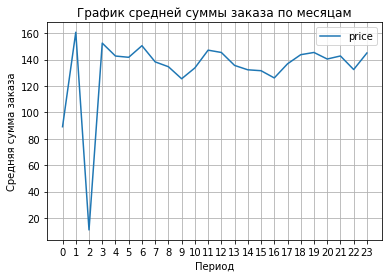

In [210]:
plt.figure(figsize=(16,8))
mean_order_price.plot()
plt.xlabel('Период')  
plt.ylabel('Средняя сумма заказа')  
plt.title('График средней суммы заказа по месяцам') 
plt.xticks(mean_order_price.index)
plt.grid()

# Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

In [216]:
#для выбора гипотезы сначала подготовим данные 
#нужно взять период с 1 июня 2017 года

actual_orders = orders.query('order_purchase_timestamp >= "2017-06-01"')
actual_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


Гипотеза 1.

Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [220]:
#проверим, сколько отмен всего было за указанный период
actual_orders.query('order_status=="canceled"').order_id.nunique()

499

In [235]:
#499 заказов - это 4 по шкале Impact. Итого 4 * 8 * 6 = 192 по шкале ICE.

Гипотеза 2.

Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

In [225]:
#проверим, сколько было заказов, где доставка опоздала
late_delivery = orders.query('order_estimated_delivery_date < order_delivered_customer_date')
late_delivery

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12
35,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02
...,...,...,...,...,...,...,...,...
99396,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,delivered,2018-08-02 22:46:54,2018-08-02 23:04:06,2018-08-15 17:42:00,2018-08-21 00:03:26,2018-08-16
99397,0fa1fab1d7c1211c824596ed5e111e3c,7f3bd6c94d2daf7b6462d1a894a775b4,delivered,2018-03-13 21:48:57,2018-03-13 22:40:28,2018-03-14 19:27:23,2018-04-05 19:59:49,2018-04-02
99423,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,2017-10-17 17:04:42,2017-11-21 17:06:59,2017-10-31
99425,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,delivered,2018-03-21 19:47:18,2018-03-21 20:05:26,2018-03-22 21:11:58,2018-04-11 00:48:31,2018-04-09


In [226]:
# Рассчитаем, на сколько в среднем опаздывала доставка.
late_delivery['late'] = (late_delivery.order_delivered_customer_date - late_delivery.order_estimated_delivery_date).dt.days
late_delivery

/tmp/ipykernel_51/791072191.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  late_delivery['late'] = (late_delivery.order_delivered_customer_date - late_delivery.order_estimated_delivery_date).dt.days


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,late
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,11
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,9
35,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20,0
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,7
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,1
...,...,...,...,...,...,...,...,...,...
99396,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,delivered,2018-08-02 22:46:54,2018-08-02 23:04:06,2018-08-15 17:42:00,2018-08-21 00:03:26,2018-08-16,5
99397,0fa1fab1d7c1211c824596ed5e111e3c,7f3bd6c94d2daf7b6462d1a894a775b4,delivered,2018-03-13 21:48:57,2018-03-13 22:40:28,2018-03-14 19:27:23,2018-04-05 19:59:49,2018-04-02,3
99423,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,2017-10-17 17:04:42,2017-11-21 17:06:59,2017-10-31,21
99425,d692ef54145c9cb3322ec2e5508aa3f4,82ddfcf9438b0cd1117b55ac33184df8,delivered,2018-03-21 19:47:18,2018-03-21 20:05:26,2018-03-22 21:11:58,2018-04-11 00:48:31,2018-04-09,2


In [227]:
#узнаем параметры опозданий
late_delivery.late.describe()

count    7827.000000
mean        8.867254
std        13.949441
min         0.000000
25%         1.000000
50%         5.000000
75%        11.000000
max       188.000000
Name: late, dtype: float64

In [233]:
#7827 опозданий. Если принять условие, что конверсия в повторный заказ равна величине медианного retention 1-го месяца,
#то получим, что в результате принятых мер общее количество заказов увеличится на 28
median_retention_1 * 7827

27.75531914893617

In [237]:
#28 - это 1 по шкале Impact. Это 1 * 10 * 4 = 40 по шкале ICE.

Гипотеза 3.

Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [242]:
#используем для этого уже заданный датафрейм c доставленными заказами и уникальными айди клиентов delivered_orders
#и отсеем клиентов, которые совершили более 1 заказа
delivered_orders.groupby('customer_unique_id').agg({'order_purchase_timestamp': 'count'}).reset_index()\
    .query('order_purchase_timestamp == 1').customer_unique_id.nunique()

90557

In [246]:
#Если принять условие, что конверсия в повторный заказ равна величине медианного retention 1-го месяца,
#то получим, что в результате принятых мер общее количество заказов увеличится на 321

In [247]:
median_retention_1 * 90557 

321.1241134751773

In [248]:
#321 - это 3 по шкале Impact. Это 3 * 5 * 9 = 135 по шкале ICE.

Итого, по шкале ICE имеем следующие результаты:


1 Гипотеза - 192

2 Гипотеза - 40

3 Гипотеза - 135

Больше всех баллов набрала 1 Гипотеза, поэтому выбираем её

# Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

Уменьшение количества отмен повлияет на следующие метрики:

Целевые:
1) выручка (за счёт большего количества совершённых заказов)

Прокси-метрики:
1) среднее количество заказов на пользователя 

Guardrail-метрики:
1) конверсию в оплату

2) конверсия в повторный заказ 


In [250]:
#Дальше мне было интересно немного углубиться в данные и поиграться с ними

In [27]:
#узнал 10 самых популярных городов наших клиентов
customers.groupby('customer_city').agg({'customer_unique_id': 'count'}).sort_values('customer_unique_id', ascending=False).head(10)

,customer_unique_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


In [28]:
#узнал 10 самых популярных штатов
customers.groupby('customer_state').agg({'customer_unique_id': 'count'}).sort_values('customer_unique_id', ascending=False).head(10)

,customer_unique_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


Отдельно узнаем, как часто продавец опаздывал с передачей товара логистической службе

In [38]:
shipping = order_items[['order_id', 'shipping_limit_date']]
shipping

,order_id,shipping_limit_date
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-19 09:45:35
1,00018f77f2f0320c557190d7a144bdd3,2017-05-03 11:05:13
2,000229ec398224ef6ca0657da4fc703e,2018-01-18 14:48:30
3,00024acbcdf0a6daa1e931b038114c75,2018-08-15 10:10:18
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-13 13:57:51
...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,2018-05-02 04:11:01
112646,fffcd46ef2263f404302a634eb57f7eb,2018-07-20 04:31:48
112647,fffce4705a9662cd70adb13d4a31832d,2017-10-30 17:14:25
112648,fffe18544ffabc95dfada21779c9644f,2017-08-21 00:04:32


In [39]:
shipping = pd.merge(orders, shipping, on = 'order_id', how = 'inner')
shipping

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-06 11:07:15
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-30 03:24:27
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-13 08:55:23
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-23 19:45:59
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-19 20:31:37
...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018-02-12 13:10:37
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017-09-05 15:04:16
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018-01-12 21:36:21
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018-01-12 21:36:21


In [88]:
late_shipping = shipping.query('shipping_limit_date < order_delivered_carrier_date')
late_shipping

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date
21,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,2017-09-25 04:04:09
30,91b2a010e1e45e6ba3d133fa997597be,cce89a605105b148387c52e286ac8335,delivered,2018-05-02 11:45:38,2018-05-03 12:55:01,2018-05-10 16:16:00,2018-05-16 20:56:24,2018-05-23,2018-05-09 12:55:01
32,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23,2017-08-17 02:45:24
43,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,2017-11-30 00:21:09
62,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,delivered,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30,2017-03-17 18:14:36
...,...,...,...,...,...,...,...,...,...
112602,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,delivered,2018-08-02 22:46:54,2018-08-02 23:04:06,2018-08-15 17:42:00,2018-08-21 00:03:26,2018-08-16,2018-08-08 23:04:06
112603,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,delivered,2018-08-02 22:46:54,2018-08-02 23:04:06,2018-08-15 17:42:00,2018-08-21 00:03:26,2018-08-16,2018-08-08 23:04:06
112621,e8fd20068b9f7e6ec07068bb7537f781,609b9fb8cad4fe0c7b376f77c8ab76ad,delivered,2017-08-10 21:21:07,2017-08-10 21:35:26,2017-08-18 16:42:51,2017-08-23 15:36:29,2017-08-31,2017-08-17 21:35:26
112622,e8fd20068b9f7e6ec07068bb7537f781,609b9fb8cad4fe0c7b376f77c8ab76ad,delivered,2017-08-10 21:21:07,2017-08-10 21:35:26,2017-08-18 16:42:51,2017-08-23 15:36:29,2017-08-31,2017-08-17 21:35:26


In [41]:
#узнаем, сколько из заказов, прибывших с опозданием задержались по вине долгого сбора заказа продавцом
pd.merge(late_delivery[['order_id', 'order_delivered_carrier_date']], late_shipping[['order_id', 'shipping_limit_date']], on='order_id', how= 'inner')

,order_id,order_delivered_carrier_date,shipping_limit_date
0,203096f03d82e0dffbc41ebc2e2bcfb7,2017-10-06 17:50:03,2017-09-25 04:04:09
1,6ea2f835b4556291ffdc53fa0b3b95e8,2017-12-13 21:14:05,2017-11-30 00:21:09
2,a685d016c8a26f71a0bb67821070e398,2017-03-22 14:03:09,2017-03-17 18:14:36
3,9d531c565e28c3e0d756192f84d8731f,2017-12-14 20:37:43,2017-12-06 20:57:24
4,fb9b2930f4a30f96c7cc98eaaa85e5f0,2017-11-30 18:18:50,2017-11-30 16:19:01
...,...,...,...
2469,25f6cb0e242a4c0bacc239397614422e,2017-11-27 22:04:13,2017-11-27 04:06:25
2470,b5d08e6b71d4af8f816daf169014c908,2017-12-11 17:21:48,2017-12-11 10:03:30
2471,141c7645c99eed7a80fa7ec9d6c40ad0,2018-01-26 21:15:16,2018-01-19 16:12:36
2472,b3112ca67f3afd4e20cf2ee91fc4f804,2018-08-15 17:42:00,2018-08-08 23:04:06


In [89]:
# теперь проверим, есть ли среди этих продавцов системно нерадивые, 
#с кем лучше стоит прекратить сотрудничество во избежание новых задержек доставки заказов.
late_shipping_sellers = pd.merge(late_shipping, order_items[['order_id', 'seller_id']], on = 'order_id', how = 'inner')\
                                .groupby('seller_id').agg({'order_id': 'nunique'}).reset_index()\
                                .sort_values('order_id', ascending = False)\
                                .rename(columns={'order_id': 'late_orders_to_shipping'})
late_shipping_sellers

,seller_id,late_orders_to_shipping
646,7c67e1448b00f6e969d365cea6b010ab,290
80,1025f0e2d44d7041d6cf58b6550e0bfa,163
373,4a3ca9315b744ce9f8e9374361493884,157
161,1f50f920176fa81dab994f9023523100,154
315,3d871de0142ce09b7081e2b9d1733cb1,140
...,...,...
1303,f8201cab383e484733266d1906e2fdfa,1
1307,f9244d45189d3a3605499abddeade7d5,1
1308,f92d8c817434bd2d84d4e9c61322b7fa,1
1312,fa3a0b5aabb344b9a92e3524b0202123,1


In [43]:
#Надо теперь проверить долю задержанных к доставленным заказам в разрезе каждого продавца.


In [76]:
#создаём сводную таблицу по количеству заказов в целом и заказов, переданных с опозданием в разрезе каждого продавца

sellers = order_items.groupby('seller_id').agg({'order_id': 'nunique'}).reset_index()
sellers

,seller_id,order_id
0,0015a82c2db000af6aaaf3ae2ecb0532,3
1,001cca7ae9ae17fb1caed9dfb1094831,200
2,001e6ad469a905060d959994f1b41e4f,1
3,002100f778ceb8431b7a1020ff7ab48f,51
4,003554e2dce176b5555353e4f3555ac8,1
...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,1
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,18
3092,ffeee66ac5d5a62fe688b9d26f83f534,14
3093,fffd5413c0700ac820c7069d66d98c89,60


In [90]:
late_shipping_sellers = pd.merge(sellers, late_shipping_sellers, on = 'seller_id', how = 'left').fillna(0)
late_shipping_sellers['late_rate'] = round(late_shipping_sellers.late_orders_to_shipping / late_shipping_sellers.order_id *100,2)
late_shipping_sellers.sort_values('late_rate', ascending=False)

,seller_id,order_id,late_orders_to_shipping,late_rate
38,0336182e1b3e92f029d5354832045fdf,1,1.0,100.0
12,010da0602d7774602cd1b3f5fb7b709e,1,1.0,100.0
50,04843805947f0fc584fc1969b6e50fe7,1,1.0,100.0
2965,f524ad65d7e0f1daab730ef2d2e86196,1,1.0,100.0
660,38874e327ce94d11390b96eb42d61928,6,6.0,100.0
...,...,...,...,...
1776,90b57083da5d803237da74daec6dcb2b,2,0.0,0.0
1773,902c99f1ac505c0d18778b61bcd636f7,4,0.0,0.0
1770,8fff28c4263ddec387f28d237fb42773,4,0.0,0.0
1793,9261d76c62caaf0b24677c2ceb7f8f20,6,0.0,0.0


In [91]:
#оставляем в таблице тех продавцов, которые продали более 5 товаров
late_shipping_sellers1 = late_shipping_sellers.query('order_id>5')
late_shipping_sellers1

,seller_id,order_id,late_orders_to_shipping,late_rate
1,001cca7ae9ae17fb1caed9dfb1094831,200,12.0,6.00
3,002100f778ceb8431b7a1020ff7ab48f,51,4.0,7.84
5,004c9cd9d87a3c30c522c48c4fc07416,158,0.0,0.00
6,00720abe85ba0859807595bbf045a33b,13,3.0,23.08
9,00ee68308b45bc5e2660cd833c3f81cc,135,1.0,0.74
...,...,...,...,...
3089,ffc470761de7d0232558ba5e786e57b7,28,0.0,0.00
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,3.0,16.67
3092,ffeee66ac5d5a62fe688b9d26f83f534,14,5.0,35.71
3093,fffd5413c0700ac820c7069d66d98c89,60,3.0,5.00


Text(0.5, 1.0, 'Зависимость количества опозданий у продавца от общего количества заказов')

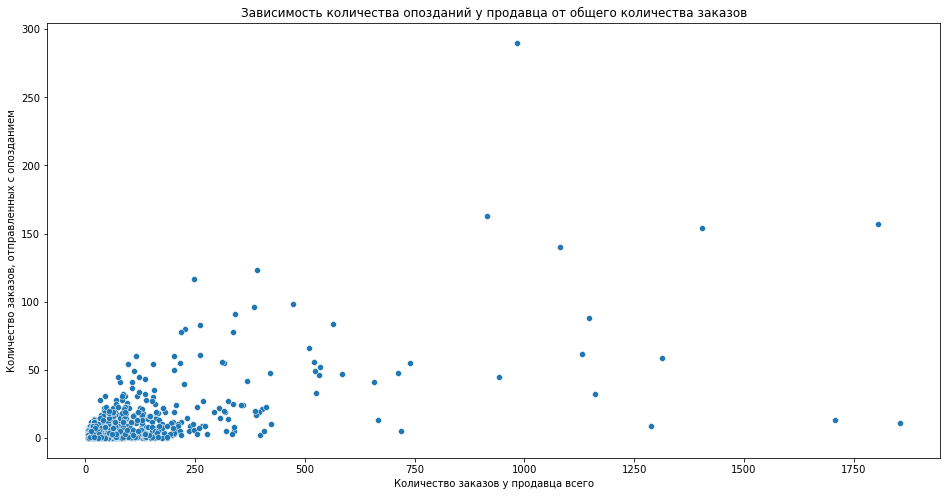

In [92]:
#график зависимости процента задержек от количества продаваемых товаров (решил посмотреть, а что будет)
plt.figure(figsize=(16,8))
sns.scatterplot(data=late_shipping_sellers1, x='order_id', y = 'late_orders_to_shipping')

plt.xlabel('Количество заказов у продавца всего') 
plt.ylabel('Количество заказов, отправленных с опозданием')
plt.title('Зависимость количества опозданий у продавца от общего количества заказов')

In [93]:
late_shipping_sellers.query('late_rate>50').seller_id.nunique()

158

In [378]:
#сколько всего с нами работает продавцов
order_items.seller_id.nunique()

3095



10423 раза продавцы передали заказ логистической службе с опозданием. 
Из-за этого 2474  раз заказы приходили с опозданием не по вине логистической службы.
По вине самой логистической службы заказы задерживались 5353 раза.

Можно утверждать, что это является одним из факторов, почему клиенты не возвращаются в наш продукт.
Получается, что в задержках доставки виноваты как продавцы, поздно передающие товары в логистическую службу, так и наши партнёры по логистике, долго везущие товары.

158 продавцов из 3095 (примерно 5%) регулярно задерживают передачу заказа в логистическую службу (более 50% заказов они передают с задержкой). Можно проработать этот вопрос

In [96]:
#проверим, в какие штаты/города больше всего было опозданий
late_delivery_city = pd.merge(late_delivery[['customer_id','late']], customers[['customer_id','customer_city']], on= 'customer_id', how = 'inner')
late_delivery_city

,customer_id,late,customer_city
0,d2b091571da224a1b36412c18bc3bbfe,11,sao paulo
1,3a874b4d4c4b6543206ff5d89287f0c3,9,rio de janeiro
2,5f16605299d698660e0606f7eae2d2f9,0,alvorada
3,c7340080e394356141681bd4c9b8fe31,7,presidente venceslau
4,684fa6da5134b9e4dab731e00011712d,1,aracaju
...,...,...,...
7822,6f83c71b6c044fb156d697d4130fe9b5,5,maua
7823,7f3bd6c94d2daf7b6462d1a894a775b4,3,sao paulo
7824,ad312389a098ceff46ce92c4595c06d0,21,araraquara
7825,82ddfcf9438b0cd1117b55ac33184df8,2,valinhos


In [97]:
#находим, на сколько в среднем дней опаздывали заказы в каждый город
late_delivery_city.groupby('customer_city').agg({'late': 'mean'}).reset_index().sort_values('late', ascending=False).head(10)


,customer_city,late
733,montanha,181.0
864,perdizes,162.0
665,macapa,144.0
779,novo brasil,126.0
943,quintana,121.0
1042,santaluz,104.0
522,itacare,81.0
237,capinzal do norte,78.0
1201,teutonia,76.5
397,formosa,76.0


Видим, что в 6 городах заказы доставлены с опозданием более чем на 100 дней. Надо проверить, это разовый инцидент или доставка постоянно происходит с большим опозданием.

In [98]:
#находим, при доставке в какой город было больше всего опозданий количественно
late_delivery_city.groupby('customer_city').agg({'late': 'count'}).reset_index().sort_values('late', ascending=False).head(10)

,customer_city,late
1126,sao paulo,942
980,rio de janeiro,780
1007,salvador,208
129,belo horizonte,166
920,porto alegre,158
159,brasilia,147
205,campinas,143
402,fortaleza,111
759,niteroi,103
1079,sao goncalo,96


Видим, что больше всего опозданий при доставке в города "sao paulo" и "rio de janeiro". 
Однако также можно заметить, что среди найденных ранее больших задержек по городам нет какой-то системности, 
и все они скорее были разовыми.

Проверим, сколько времени в среднем проходит между созданием и оплатой заказа

In [105]:
pick_order = orders.query('order_status == "delivered"')[['order_id', 'order_purchase_timestamp', 'order_approved_at']]
pick_order['time_to_purchase'] = pick_order.order_approved_at - pick_order.order_purchase_timestamp
pick_order

,order_id,order_purchase_timestamp,order_approved_at,time_to_purchase
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,0 days 00:10:42
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07-26 03:24:27,1 days 06:42:50
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-08 08:55:23,0 days 00:16:34
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11-18 19:45:59,0 days 00:17:53
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-13 22:20:29,0 days 01:01:50
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,2017-03-09 09:54:05,0 days 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,2018-02-06 13:10:37,0 days 00:11:39
99438,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,2017-08-27 15:04:16,0 days 00:17:33
99439,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,2018-01-08 21:36:21,0 days 00:07:54


In [107]:
pick_order.time_to_purchase.mean()

#среднее время - 10 часов и 16 минут

Timedelta('0 days 10:16:36.361243572')

In [108]:
pick_order.time_to_purchase.max()

Timedelta('30 days 21:26:37')